**PRACTICE WITH SOLUTIONS**

---



Things to remember:


# Machine Learning terms and metrics

Module 1, Lab 2

In this lab, we will show a part of the ML pipeline by using the California Housing dataset. There are 20640 samples, each with 8 attributes like income of the block, age of the houses per district etc. The task is to predict the cost of the houses per district. We will use the scikit-learn library to load the data and perform some basic data preprocessing and model training. We will also show how to evaluate the model using some common metrics, split the data into training and testing sets, and use cross-validation to get a better estimate of the model's performance.

## Common Machine Learning Evaluation Metrics

### Classification Metrics

**1. Accuracy**
$$\text{Accuracy} = \frac{\text{Correct Predictions}}{\text{Total Predictions}} = \frac{TP + TN}{TP + TN + FP + FN}$$

**2. Precision** (How many predicted positives are actually positive?)
$$\text{Precision} = \frac{TP}{TP + FP}$$

**3. Recall/Sensitivity** (How many actual positives did we find?)
$$\text{Recall} = \frac{TP}{TP + FN}$$

**4. F1-Score** (Harmonic mean of Precision and Recall)
$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

Where: **TP** = True Positives, **TN** = True Negatives, **FP** = False Positives, **FN** = False Negatives

### Regression Metrics

**1. Mean Absolute Error (MAE)**
$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n}|y_i - \hat{y}_i|$$

**2. Mean Squared Error (MSE)**
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

**3. Root Mean Squared Error (RMSE)**
$$\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$$

---

In [2]:
import numpy as np
from sklearn import datasets
import matplotlib.pyplot as plt


rng=np.random.default_rng(seed=42)

In [3]:
dataset=datasets.fetch_california_housing()
# printing the dataset
print(dataset)

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]]), 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]), 'frame': None, 'target_names': ['MedHouseVal'], 'feature_names': ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude'], 'DESCR': '.. _california_housing_dataset:\n\nCalifornia Housing dataset\n-

In [4]:
print("original target values:",dataset.target)
#converting it to int
dataset.target=dataset.target.astype(int)

print("after the conversion",dataset.target)
#number of elements
print("input variable shapes",dataset.data.shape)

print("output variable shapes",dataset.target.shape)

original target values: [4.526 3.585 3.521 ... 0.923 0.847 0.894]
after the conversion [4 3 3 ... 0 0 0]
input variable shapes (20640, 8)
output variable shapes (20640,)


In [5]:
def k_model(traindata,trainlabel,query):
  # This function takes in the training data, training labels and a query point
    # and returns the predicted label for the query point using the nearest neighbour algorithm
    k=(
        traindata-query
    )
    sq=k*k
    dist=sq.sum(1)
    label=trainlabel[np.argmin(dist)]
    return label
def NN(traindata,trainlabel,testdata):
  # This function takes in the training data, training labels and testing data
  predlabel = np.array([k_model(traindata, trainlabel, i) for i in testdata])
  return predlabel
  #this gives the predicted labels of evry point of each test point


In [6]:
def randomClassifier(traindata,trainlabel,testdata):
    classes = np.unique(trainlabel)
    rints = rng.integers(low=0, high=len(classes), size=len(testdata))
    predlabel = classes[rints]
    return predlabel



  This function takes in the training data, training labels and test data
    and returns the predicted labels for the test data using the random classifier algorithm

    In reality, we don't need these arguments but we are passing them to keep the function signature consistent with other classifiers

    traindata: numpy array of shape (n,d) where n is the number of samples and d is the number of features
    trainlabel: numpy array of shape (n,) where n is the number of samples
    testdata: numpy array of shape (m,d) where m is the number of test samples and d is the number of features

    returns: the predicted labels for the test data which is a random label from the training data

In [7]:
def Accuracy(gtlabel, predlabel):
    """
    This function takes in the ground-truth labels and predicted labels
    and returns the accuracy of the classifier

    gtlabel: numpy array of shape (n,) where n is the number of samples
    predlabel: numpy array of shape (n,) where n is the number of samples

    returns: the accuracy of the classifier which is the number of correct predictions divided by the total number of predictions
    """
    assert len(gtlabel) == len(
        predlabel
    ), "Length of the ground-truth labels and predicted labels should be the same"
    correct = (
        gtlabel == predlabel
    ).sum()  # count the number of times the groundtruth label is equal to the predicted label.
    return correct / len(gtlabel)

Let us make a function to split the dataset with the desired probability. We will use this function to split the dataset into training and testing sets. We will use the training set to train the model and the testing set to evaluate the model.

In [8]:
def split(data, label, percent):
    # generate a random number for each sample
    rnd = rng.random(len(label))
    split1 = rnd < percent
    split2 = rnd >= percent

    split1data = data[split1, :]
    split1label = label[split1]
    split2data = data[split2, :]
    split2label = label[split2]
    return split1data, split1label, split2data, split2label

In [9]:
testdata, testlabel, alltraindata, alltrainlabel = split(
    dataset.data, dataset.target, 20 / 100
)
print("Number of test samples:", len(testlabel))
print("Number of train samples:", len(alltrainlabel))
print("Percent of test data:", len(testlabel) * 100 / len(dataset.target), "%")
#why is this done??
# 🧠 Training data (alltraindata, alltrainlabel)
# Used to build/learn the model
# The model sees this data
# 2. 🧪 Test data (testdata, testlabel)
# Used to evaluate the model
# The model has never seen this before

Number of test samples: 4144
Number of train samples: 16496
Percent of test data: 20.07751937984496 %


In [33]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 0.5)

In [34]:
from sklearn.metrics import confusion_matrix,f1_score,precision_score,recall_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
def print_classification_metrics(true_labels,pred_labels):
  precision=precision_score(true_labels,pred_labels,average='macro',zero_division=0)
  recall=recall_score(true_labels,pred_labels,average='macro',zero_division=0)
  f1=f1_score(true_labels,pred_labels,average='macro',zero_division=0)
  accuracy=np.mean(true_labels==pred_labels)
  print(f"Accuracy:  {accuracy*100:.2f}%")
  print(f"Precision: {precision*100:.2f}%")
  print(f"Recall:    {recall*100:.2f}%")
  print(f"F1-Score:  {f1*100:.2f}%")

  return accuracy, precision, recall, f1

  def print_regression_metrics(true_values, pred_values):
    """
    Calculate and print regression metrics
    """
    mae = mean_absolute_error(true_values, pred_values)
    mse = mean_squared_error(true_values, pred_values)
    rmse = np.sqrt(mse)

    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")

    return mae, mse, rmse

# Example: Evaluate validation set with multiple metrics
print("=== Validation Set Classification Metrics ===")
valpred = NN(traindata, trainlabel, valdata)
print_classification_metrics(vallabel, valpred)


=== Validation Set Classification Metrics ===
Accuracy:  33.24%
Precision: 24.87%
Recall:    23.62%
F1-Score:  24.08%


(np.float64(0.33243836953868683),
 0.24866849709482408,
 0.23619580371942114,
 0.24080123481744187)

=== Confusion Matrix for Validation Set ===


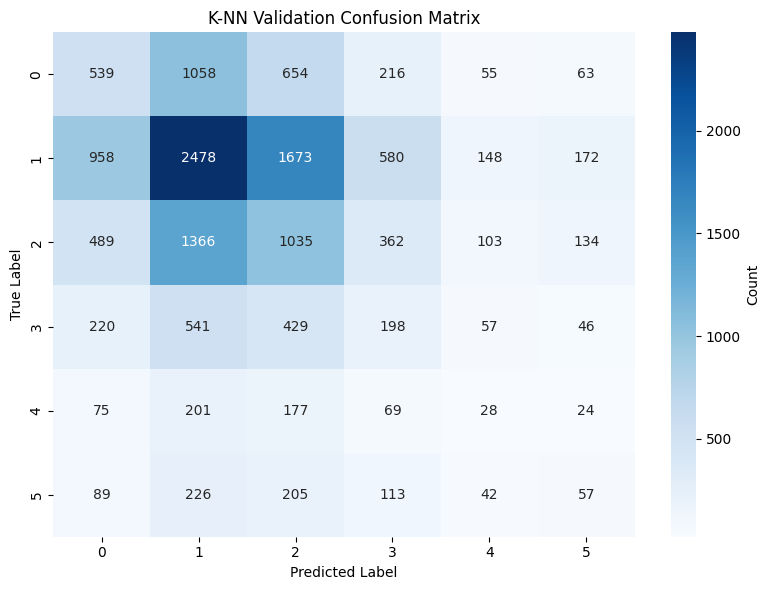

Confusion Matrix Shape: (6, 6)
Total Predictions: 14880


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(true_labels, pred_labels, title="Confusion Matrix"):
    """
    Plot confusion matrix heatmap
    """
    cm = confusion_matrix(true_labels, pred_labels)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                cbar_kws={'label': 'Count'})
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    print(f"Confusion Matrix Shape: {cm.shape}")
    print(f"Total Predictions: {cm.sum()}")

# Visualize confusion matrix for validation predictions
print("=== Confusion Matrix for Validation Set ===")
valpred = NN(traindata, trainlabel, valdata)
plot_confusion_matrix(vallabel, valpred,
                     title="K-NN Validation Confusion Matrix")

Accuracy is given by the

 number of correct predictions ,by total number of predictions

In [30]:
trainpred = NN(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using nearest neighbour algorithm:", trainAccuracy*100, "%")

trainpred = randomClassifier(traindata, trainlabel, traindata)
trainAccuracy = Accuracy(trainlabel, trainpred)
print("Training accuracy using random classifier: ", trainAccuracy*100, "%")

Training accuracy using nearest neighbour algorithm: 100.0 %
Training accuracy using random classifier:  17.26485148514851 %


what can we conclude by seeing above measures is that,NN performs perfectly on training data but may not generalize well; random classifier performs poorly as expected.

In [31]:
traindata, trainlabel, valdata, vallabel = split(
    alltraindata, alltrainlabel, 75 / 100)
valpred = NN(traindata, trainlabel, valdata)
valAccuracy = Accuracy(vallabel, valpred)
print("Validation accuracy using nearest neighbour algorithm:", valAccuracy*100, "%")

Validation accuracy using nearest neighbour algorithm: 33.004926108374384 %


In [32]:
testpred = NN(alltraindata, alltrainlabel, testdata)
testAccuracy = Accuracy(testlabel, testpred)

print("Test accuracy:", testAccuracy*100, "%")

Test accuracy: 34.91795366795367 %


1.The accuracy of the validation set is affected when we increasethe percentage of validation set, the accuracy decreases because the training set is less,when we increase the validation set ,the accuracy is 1 ,but the results  are not matched

2.When the training set is large and the validation set is small, the nearest neighbour model learns better because it has more data to train on, but the validation accuracy becomes unreliable as an estimate of test accuracy due to the small size of the validation set. On the other hand, when the training set is small and the validation set is large, the model performs worse because it does not have enough data to learn effectively, although the validation accuracy becomes more stable and reliable for evaluation.

3.I guess the good percentage can be 50% where you wll have good amount of data to learn and validate .Not more than 50 but not less than 20,a good window of 20-50

In [38]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1-NN model
knn1 = KNeighborsClassifier(n_neighbors=1)
knn1.fit(alltraindata, alltrainlabel)

pred1 = knn1.predict(testdata)
acc1 = accuracy_score(testlabel, pred1)

print("Test Accuracy (1-NN):", acc1 * 100, "%")


# 3-NN model
knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(alltraindata, alltrainlabel)

pred3 = knn3.predict(testdata)
acc3 = accuracy_score(testlabel, pred3)

print("Test Accuracy (3-NN):", acc3 * 100, "%")

Test Accuracy (1-NN): 34.91795366795367 %
Test Accuracy (3-NN): 36.05212355212355 %


The 3-nearest neighbour classifier achieves slightly higher test accuracy (≈36.05%) compared to the 1-nearest neighbour classifier (≈34.92%). This is because 1-NN overfits the training data, while 3-NN considers multiple neighbours, reducing noise and improving generalization.

**ANSWERS**
1.Yes,reduces randomness,
2.Yes,
3.Yes,when we iterate more ,maybe the data is more refined and stable





**EXERCISE SOLUTION**->

1-NN is very sensitive to how you split the data. Its accuracy can change a lot with different splits, and it usually overfits  it gets very high training accuracy but doesn’t perform as well on validation or test data. On the other hand, 3-NN is more stable. It doesn’t get affected as much by small changes , and since it looks at multiple neighbours, it generally gives better and more consistent results.